### 5. Generate a regression dataset with heteroscedastic noise.Train a linear regression model.
#### a. Compare Mean Squared Error (MSE) and log-likelihood based loss.
#### b. Interpret results probabilistically.

Mean Squared Error: 4.89013057643254
Log-Likelihood: -663.7644108429831


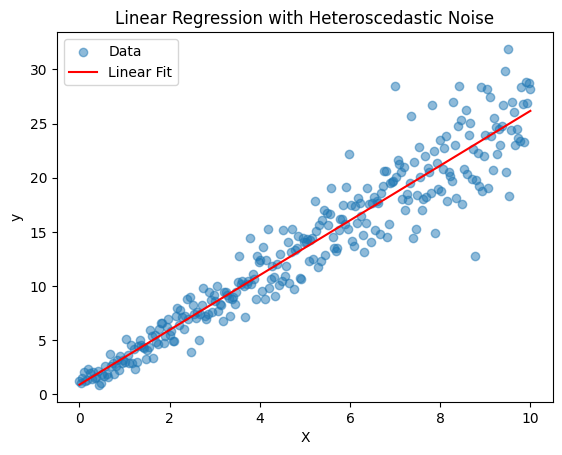

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

n = 300
X = np.linspace(0, 10, n).reshape(-1, 1)

true_w = 2.5
true_b = 1.0

# Noise variance increases with X (heteroscedastic)
sigma = 0.5 + 0.3 * X.flatten()
noise = np.random.normal(0, sigma)

y = true_w * X.flatten() + true_b + noise


lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)


mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)


residuals = y - y_pred
sigma_hat = np.var(residuals)


log_likelihood = -0.5 * np.sum(
    np.log(2 * np.pi * sigma_hat) +
    (residuals**2) / sigma_hat
)

print("Log-Likelihood:", log_likelihood)


import matplotlib.pyplot as plt

plt.scatter(X, y, alpha=0.5, label="Data")
plt.plot(X, y_pred, color="red", label="Linear Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression with Heteroscedastic Noise")
plt.legend()
plt.show()



### MSE optimization is equivalent to MLE only under constant noise variance. When noise is heteroscedastic, MSE remains a valid error metric but no longer corresponds to maximizing the true data likelihood

### In the presence of heteroscedastic noise, standard linear regression optimized using MSE fails to model input-dependent uncertainty. While MSE provides a measure of average prediction error, the Gaussian log-likelihood reveals probabilistic miscalibration due to incorrect constant-variance assumptions. This highlights the need for variance-aware or weighted regression models in heteroscedastic settings.